<a href="https://colab.research.google.com/github/sambee5/data-science-coursework/blob/main/SamaBhatU4proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import graphviz as gv
import pymc as pm

# Unit 4 Project: Using Hierarchies to Account for Dependence Between Groups

**Task**:

Two parts:

1. Propose a data set that's compatible with a hierarchical model structure built with pymc, and that potentially has some dependence between subgroups within the data set. I must approve your submission before you move on to part 2.

2. Create, analyze, and present a model using pymc within the colab environment, on a data set of your choice, with the following restrictions
- You must have at least one piror and at least one hyperprior.
- Your model must have at least one seperate prior for each subgroup of the data set, and a at least one shared hyperior for all the groups.
- Any student may use the following data set: [basketball2324](https://github.com/thedarredondo/data-science-fundamentals/blob/main/Data/basketball2324.csv). I recommend trying to model TRB (total rebounds) by player position (pos). Also, I recommend pandas query function to splice and clean the data.



**I will be studying the relation between the country an athlete is from, and how that affects the time that they swim in the 100 long course freestyle.**

Begin with data wrangling! We'll be preparing all the data relevant to this analysis, specifically the Men's 100 freestyle LCM. I'm pretty sure that this data is from 2022 and before. The most notable additions are the times swam at the 2024 Olympic Games, with a world record 46:40 swim. David Popovici (the swimming with the fastest time below) also lowered his own European record to a 46:51.

I think relating the country a swimmer represents (aka Team Name) with the time they swim would yield some interesting results, as it would provide some insight on how strong the countries swimming programs are. As someone who only knows about USA swimming, I'm curious to see how the models give me insight into how other countries excel in the sport. There is definetely some dependence between the groups because some swim programs are better than others and therefore produce the best swimmers consistently.

In [2]:
swimming_data = "https://raw.githubusercontent.com/sambee5/data-science-coursework/refs/heads/main/Unit4/Swimming_database_2%5B1%5D.csv"
swimming_data = pd.read_csv(swimming_data)
swimming_data = swimming_data[swimming_data['Event description'] == 'Men 100 Freestyle LCM Male']

swimming_data = swimming_data[["Swim time", "Team Name", "Athlete Full Name"]]
swimming_data = swimming_data.rename(columns={'Swim time': 'swim_time'})
# Convert 'swim_time' to a numeric type, handling potential errors (used Gemini for this)
swimming_data['swim_time'] = pd.to_numeric(swimming_data['swim_time'], errors='coerce')

# I am removing Japan, South, Africa, and Belgium because of a lack of data from swimmers from those countries
#They would mess with my analysis later so I'll break the 4th wall and stop that from happening
#I created an appendix at the bottom of this notebook with reasons for why I removed these specific countries
teams_to_remove = ['Japan', 'South Africa', 'Belgium', 'ROC', 'Republic of Korea','Sweden']
swimming_data = swimming_data[~swimming_data['Team Name'].isin(teams_to_remove)]

swimming_data

,swim_time,Team Name,Athlete Full Name
0,46.86,Romania,"POPOVICI, David"
1,46.91,Brazil,"CIELO FILHO, Cesar"
2,46.94,France,"BERNARD, Alain"
3,46.96,United States of America,"DRESSEL, Caeleb"
4,46.98,Romania,"POPOVICI, David"
...,...,...,...
195,47.88,Russian Federation,"MOROZOV, Vladimir"
196,47.88,United States of America,"JACKSON, Tate"
197,47.88,United States of America,"PIERONI, Blake"
198,47.88,Canada,"CONDORELLI, Santo"


The athlete full name doesn't have anything to do with the analysis I'll be carrying out, but I'm keeping it here for now so I can process the data in my head easier (I know who some of the people are).

In [3]:
team_encode = pd.Categorical(swimming_data['Team Name'])

team_idx = team_encode.codes

#stores the category names in a dictionary
#this dictionary format is required
#for pymc to properly read the categories
team_coords = {"Team Name": team_encode.categories}
team_coords

{'Team Name': Index(['Australia', 'Brazil', 'Canada', 'France', 'Great Britain', 'Hungary',
        'Italy', 'Netherlands', 'People's Republic of China', 'Romania',
        'Russian Federation', 'United States of America'],
       dtype='object')}

I made categories that each swmming must fall under.

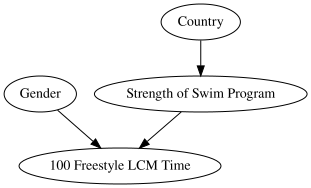

In [4]:
dag_cs_aa = gv.Digraph(comment='swim_dag')


dag_cs_aa.node('T','Strength of Swim Program')
dag_cs_aa.node('D','100 Freestyle LCM Time')

dag_cs_aa.node('G', 'Country')

dag_cs_aa.node('Q', 'Gender')

dag_cs_aa.edges(['TD','QD','GT'])
dag_cs_aa

Here is the ideal structure for interpreting this project. You should know the gender and country of someone to have some insight towards what their swim time is. This logic is similar to the aforementioned one, where the country offers insight into the strength of the swim program (such as how many medalists there are at the Olympics from a given country). The gender doesn't really matter for my anaylsis, because I'm only truly analyzing the men's 100 freestyle. This narrows the scope of the project, which hopefully yields more precise results.

Since I am unable to find a useful metric to determine the strength of swim program for a given country, I'll just use country as a proxy for the strength of swim program because I've deemed that they are closely linked. For example, a swim program from third world country like Ghana will many times, if not always, produce a weaker swimmer than one from the USA. Therefore, I'll just stick with the DAG below!

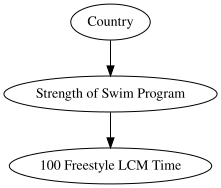

In [5]:
dag_cs_aa = gv.Digraph(comment='swim_dag')

dag_cs_aa.node('T','Strength of Swim Program')
dag_cs_aa.node('D','100 Freestyle LCM Time')

dag_cs_aa.node('G', 'Country')


dag_cs_aa.edges(['TD','GT'])
dag_cs_aa

## **Non Hierarchical**

In [ ]:
with pm.Model(coords=team_coords) as free_nh_model:
    #priors
    #dims="aa" means to apply the prior seperately to each amino acid
    μ = pm.Normal('μ_p', mu=47, sigma=10,
                  dims="Team Name")
    σ = pm.HalfNormal('σ', sigma=1.5,
                      dims="Team Name")


    #The idx variable tells my model which diffs belong to the same amino acid
    #this will cause my model to generate a posterior for each amino acid
    y = pm.SkewStudentT('y',
                  a = 1,
                  b = 1,
                  mu = μ[team_idx],
                  sigma = σ[team_idx],
                  observed=swimming_data.swim_time)

    #cs for chemshift, nh for nonheirarchical
    idata_cs_nh = pm.sample(target_accept = 0.95)

I tried experimenting with different distributions to use for my likelihood. None of them really matched my observed data really well. I kind of just picked the one that sounded the coolest in the end, but I also think that the SkewStudentT distribution fit the data the best. The observed data has a really weird skew that needs to be matched, and it's difficult to find a distribution that matches those requirements.

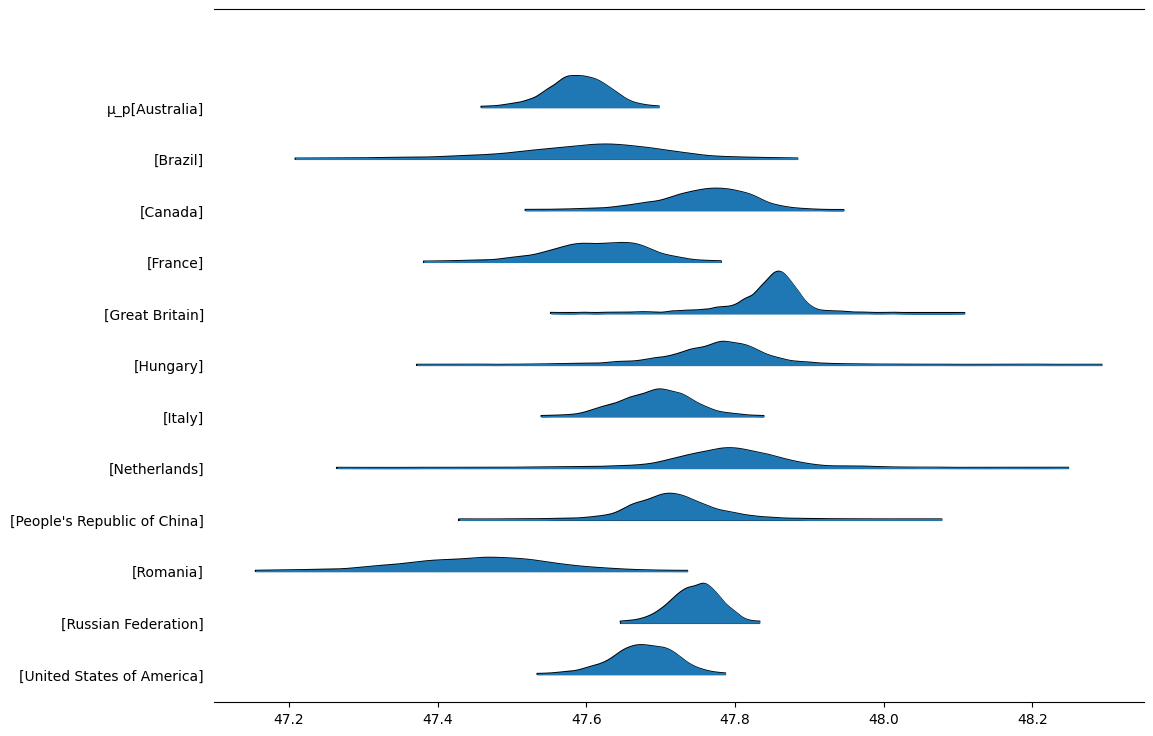

In [7]:
axes = az.plot_forest(idata_cs_nh, kind="ridgeplot",
                      var_names='μ_p',
                      combined=True, figsize=(12, 9), hdi_prob=0.997)

The skews are a bit over emphasized on every distribution across the board, but I think it's alright. Other than the Netherlands and Hungary, nothing is too bad... I also like this because it puts Romania and Brazil at the fastest times, which is accurate to the true data.

(Brazil had a really good swimmer, and Romania has a young freestyler who had the world record at the time the data was recorded)

In [ ]:
pm.sample_posterior_predictive(idata_cs_nh, model=free_nh_model, extend_inferencedata=True)

(46.0, 49.0)

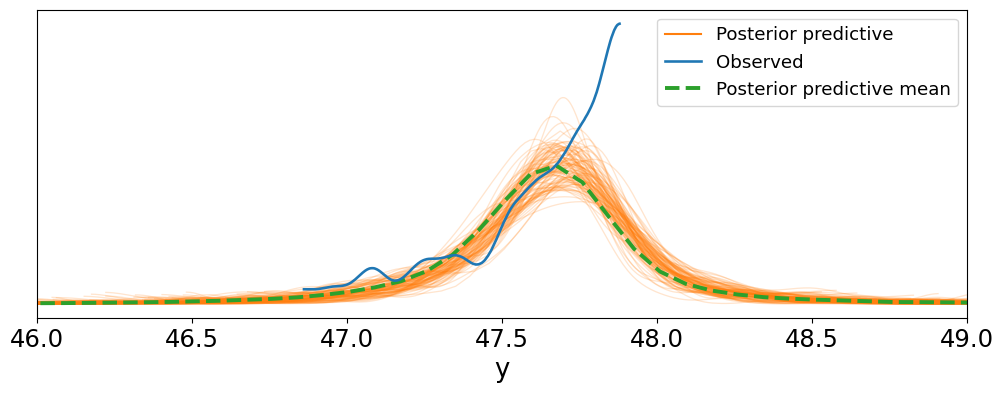

In [9]:
ax=az.plot_ppc(idata_cs_nh, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C2"])
# ax.set_xlim(-5, 5)
ax.set_xlim(46,49)

# **Hierarchical Model**


The difference between the non hierarchical and hierarchical models is insignificant. They appear to have the same outcome and predictive power when it comes to the country. I experienced a bit of difficulty when it came to matching the peak of the observed data.


In [ ]:
with pm.Model(coords=team_coords) as free_h_model:
    #hyperpriors
    μ = pm.Normal('μ', mu = 47.5, sigma = 2)
    σ = pm.Normal('ν', mu = 3, sigma = 1)
    #priors
    #dims="aa" means to apply the prior seperately to each amino acid
    μ_p = pm.Normal('μ_p', mu=μ, sigma=σ,
                  dims="Team Name")
    σ_p = pm.HalfNormal('σ_p', sigma=σ,
                      dims="Team Name")

    #The idx variable tells my model which diffs belong to the same amino acid
    #this will cause my model to generate a posterior for each amino acid
    y = pm.Normal('y',
                  mu = μ_p[team_idx],
                  sigma = σ_p[team_idx],
                  observed=swimming_data.swim_time)

    #cs for chemshift, nh for nonheirarchical
    idata_cs_h = pm.sample(target_accept = 0.95)

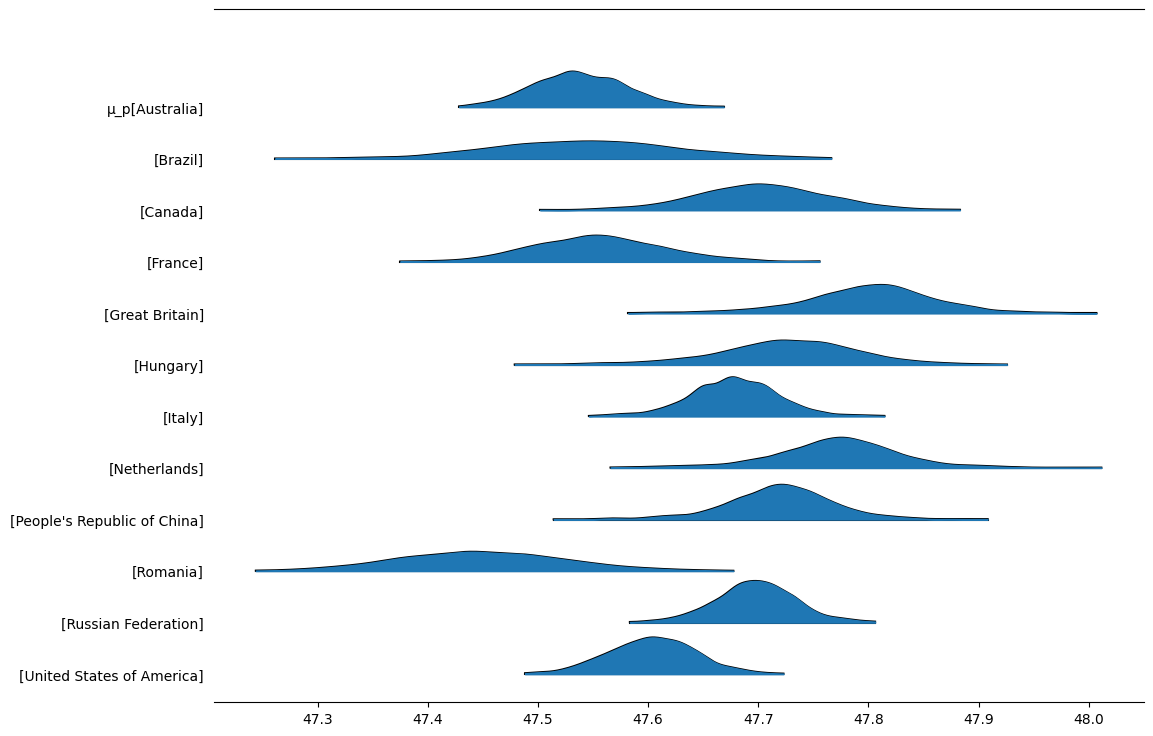

In [11]:
axes = az.plot_forest(idata_cs_h, kind="ridgeplot",
                      var_names='μ_p',
                      combined=True, figsize=(12, 9), hdi_prob=0.997)

The skew is a lot better than before. I think this is because I switched to a normal likelihood.

In [ ]:
pm.sample_posterior_predictive(idata_cs_h, model=free_h_model, extend_inferencedata=True)

(46.0, 49.0)

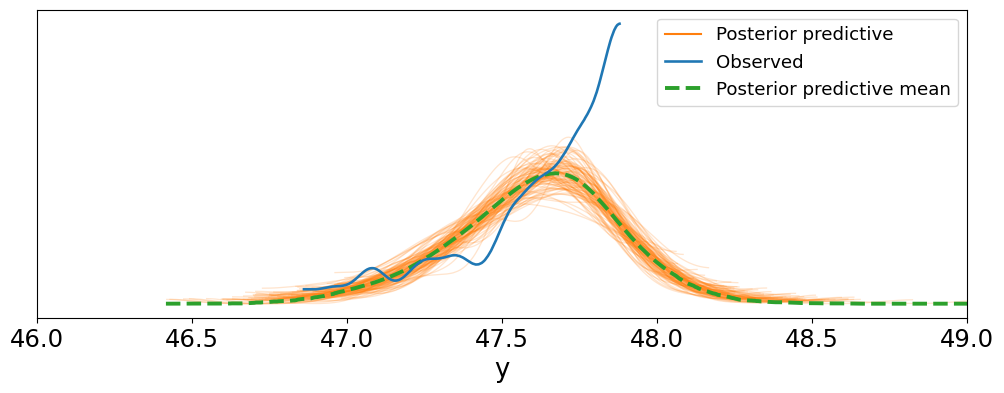

In [13]:
ax=az.plot_ppc(idata_cs_h, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C2"])
# ax.set_xlim(-5, 5)
ax.set_xlim(46,49)

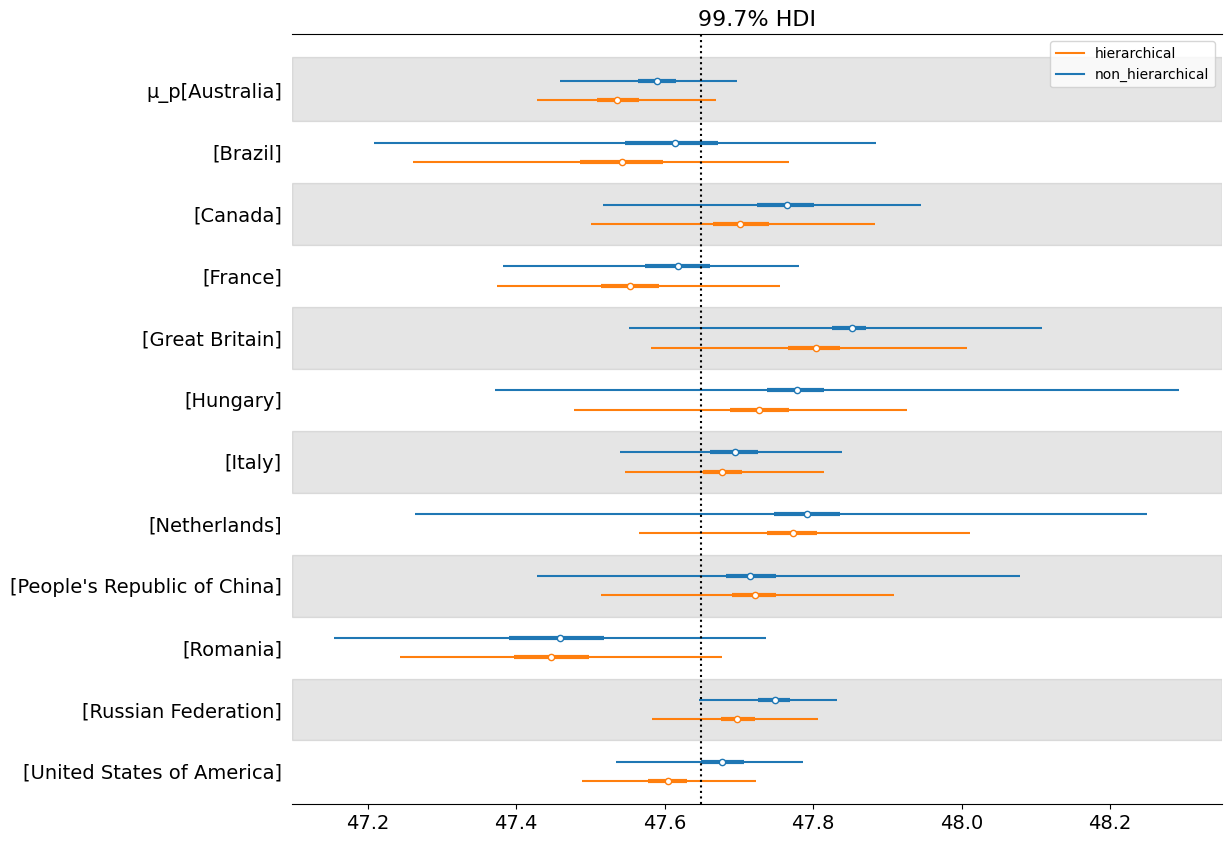

In [14]:
#plots a 99.7% hdi for the posteriors of both models on the same plot
axes = az.plot_forest([idata_cs_nh, idata_cs_h], kind="forestplot",
                      model_names=['non_hierarchical', 'hierarchical'],
                      var_names='μ_p', combined=True, figsize=(12, 10),hdi_prob=0.997)

#plots overall mean of the hierarchical model; do not confuse with 0
y_lims = axes[0].get_ylim()
axes[0].vlines(idata_cs_h.posterior['μ_p'].mean(), *y_lims, color="k", ls=":");

According to the ridgeplot above, it seems like the hierarchical model is a lot more accurate in its guesses. That is a good sign of precision. However, when I plot their respective ppc's, I can't really pick out a big difference between the two.

array([[<Axes: title={'center': 'μ'}>, <Axes: title={'center': 'μ'}>],
       [<Axes: title={'center': 'μ_p'}>, <Axes: title={'center': 'μ_p'}>],
       [<Axes: title={'center': 'ν'}>, <Axes: title={'center': 'ν'}>],
       [<Axes: title={'center': 'σ_p'}>, <Axes: title={'center': 'σ_p'}>]],
      dtype=object)

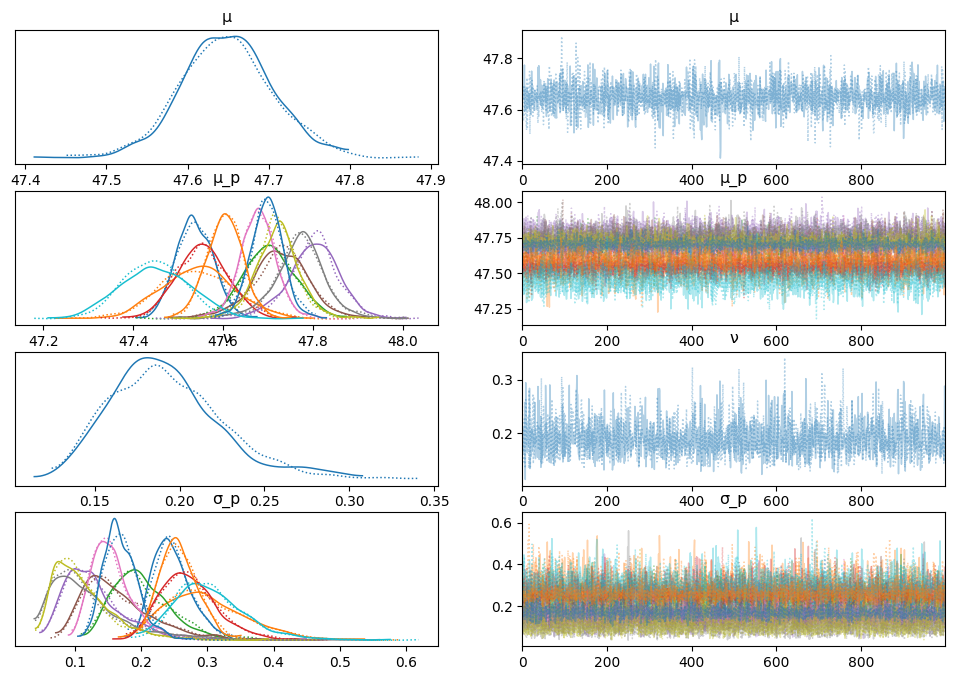

In [17]:
az.plot_trace(idata_cs_h)

In [16]:
az.rhat(idata_cs_h)

<xarray.Dataset> Size: 1kB
Dimensions:    (Team Name: 12)
Coordinates:
  * Team Name  (Team Name) <U26 1kB 'Australia' ... 'United States of America'
Data variables:
    μ          float64 8B 0.9995
    μ_p        (Team Name) float64 96B 1.001 1.0 0.9995 ... 1.003 1.001 0.9998
    ν          float64 8B 0.9999
    σ_p        (Team Name) float64 96B 0.9998 1.001 1.001 ... 0.9996 1.002 1.005

# **Appendix**
Japan: lack of swimmers

South Africa: lack of swimmers

Belgium: lack of swimmers

ROC: lack of swimmers

Republic of Korea: lack of swimmers

Sweden: 5 data points, but all by the same swimmer (I didn't think it'd be fair to judge a country's swimming ability based on 1 really good swimmer)